<a href="https://colab.research.google.com/github/franciscamandas/PRAKTIKUM-ADW/blob/main/TUGAS_2_Responsi_ADW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [2]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1045)
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 0.5 * 45
beta0 = 10 + 45
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


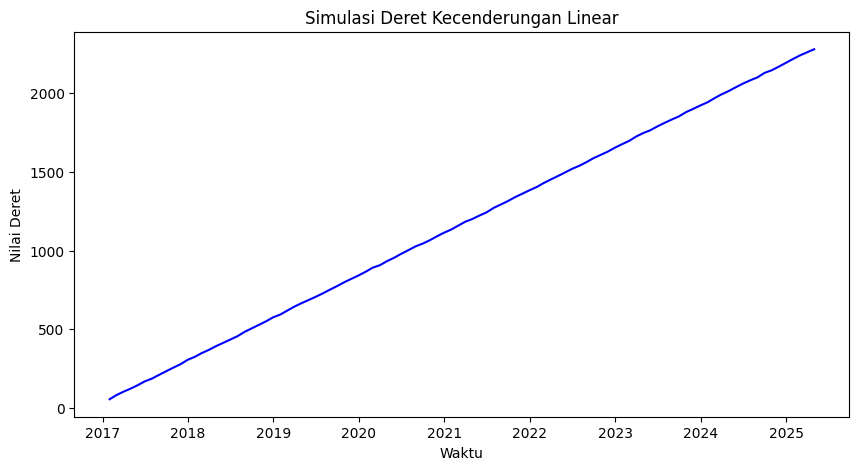

In [3]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

Cek apakah ada korelasi antar pengamatan?

In [9]:
corr = df["Value"].corr(df["Value"].shift(1))

print(f"Korelasi: {corr:.4f}")

Korelasi: 1.0000


Terdapat korelasi positif sempurna antar pengamatan. Hal ini menunjukkan hubungan linear yang sangat kuat antara nilai pada suatu periode dengan periode sebelumnya.

In [4]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [5]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.043e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.75e-248
Time:                        12:25:41   Log-Likelihood:                -210.76
No. Observations:                 100   AIC:                             425.5
Df Residuals:                      98   BIC:                             430.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           54.8242      0.399    137.314   

Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?

Hasil pengepasan model regresi menghasilkan persamaan $\hat{Y}=54.8242 + 22.5052 Time\_Numeric$.  
Nilai estimasi parameter yang diperoleh adalah $\hat{\beta}_0=54.8242$ untuk intersep dan $\hat{\beta}_1=22.5052$ untuk koefisien waktu.
Nilai tersebut sangat dekat dengan parameter asli yang digunakan dalam simulasi, sehingga dapat dikatakan bahwa model regresi mampu mengestimasi parameter asli dengan sangat baik.

Apakah model regresi yang dipaskan sudah bagus?

Ya, model regresi yang dipaskan sudah sangat baik. Hal ini ditunjukkan oleh nilai $R^2=1.000$, yang berarti sekitar $100\%$ variasi pada $Y$ dapat dijelaskan oleh variabel $Time\_Numeric$. Selain itu, koefisien $Time\_Numeric$ signifikan secara statistik dengan $p\text{-value}<0.001$, sehingga terdapat hubungan linear yang signifikan antara waktu dan nilai pengamatan. Dengan demikian, model regresi yang diperoleh dapat dikatakan sangat baik dalam menggambarkan data simulasi.

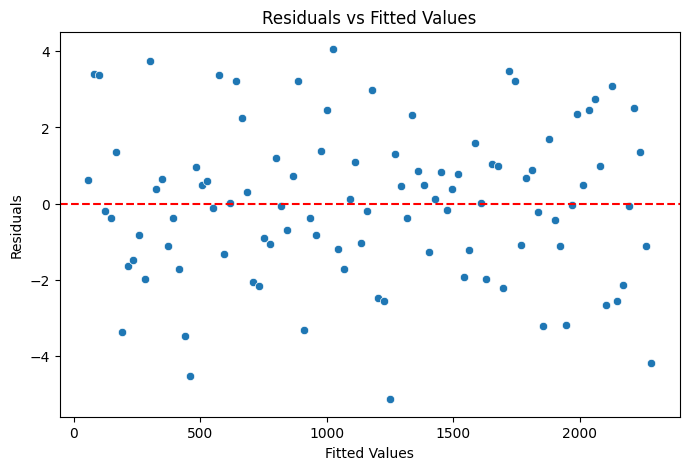

In [6]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


Apa interpretasi dari plot tersebut?

Plot menunjukkan bahwa residual tersebar di sekitar garis horizontal dan tidak membentuk pola tertentu yang jelas. Titik residual berada di atas dan di bawah garis dengan penyebaran yang relatif acak. Hal ini menunjukkan bahwa tidak terdapat pola sistematis pada residual dan varians residual cenderung relatif konstan.

In [7]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.9966


Apa kesimpulan dari nilai uji Breusch Pagan tersebut?

Hipotesis yang digunakan:

$H_0$ : Tidak terdapat hetereskedastisitas (residual bersifat homogen)

$H_1$ : Terdapat heteroskedastisitas

Dari uji Breusch-Pagan diperoleh nilai $p\text{-value}$ = 0.9966. Karena nilai > 0.05, maka $H_0$ tidak ditolak. Artinya, tidak ditemukan adanya cukup bukti heteroskedastisitas pada residual. Penyebaran atau varians residual dapat dianggap relatif konstan, sehingga asumsi homoskedastisitas terpenuhi.

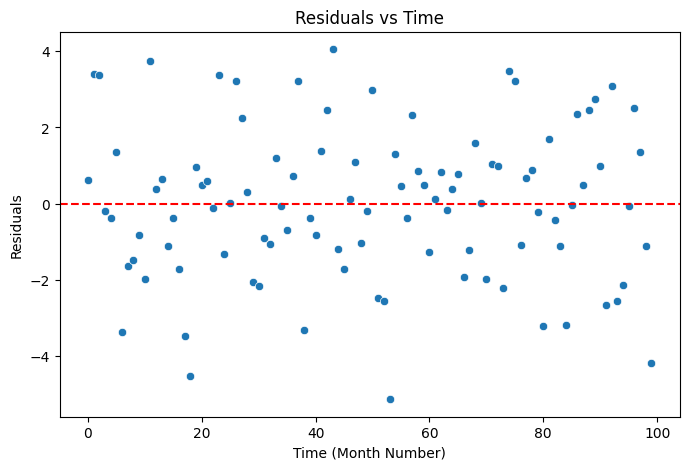

In [8]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

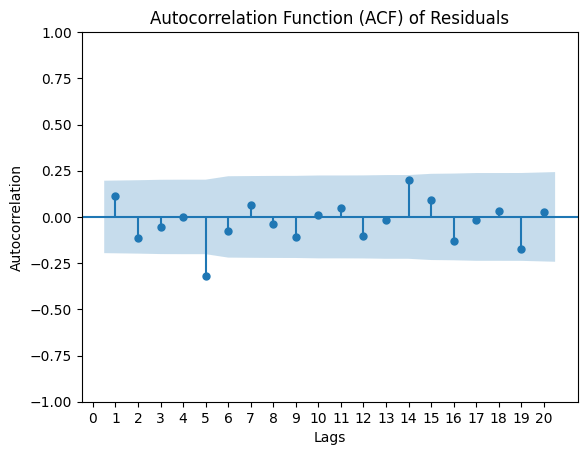

In [9]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


Apa yang dapat Anda simpulkan dari plot di atas?

Dari plot ACF residual di atas, dapat dilihat bahwa hampir semua nilai autokorelasi berada di dalam batas kepercayaan. Namun, terdapat satu spike yang cukup jelas pada lag ke-5 yang berada di luar batas kepercayaan. Artinya, sebagian residual tidak menunjukkan autokorelasi yang signifikan, tetapi terdapat indikasi autokorelasi pada lag ke-5. Jadi, secara keseluruhan residual sudah cukup acak, tetapi masih terdapat sedikit pola ketergantungan pada lag ke-5.

In [10]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    1.383351   0.239531
2    2.695507   0.259823
3    2.998121   0.391915
4    2.998124   0.558139
5   13.948842   0.015938
6   14.601501   0.023593
7   15.071766   0.035090
8   15.255477   0.054364
9   16.570323   0.055886
10  16.581188   0.084160
11  16.874788   0.111634
12  18.107759   0.112458
13  18.132298   0.152560
14  22.904001   0.061850
15  23.921377   0.066441
16  26.017515   0.053782
17  26.051234   0.073532
18  26.193181   0.095422
19  30.074546   0.050857


Apa kesimpulan dari hasil uji Ljung-Box tersebut?

Hipotesis yang digunakan:

$H_0$: Tidak terdapat autokorelasi pada residual sampai lag tertentu

$H_1$: Terdapat autokorelasi pada residual sampai lag tertentu

Dari hasil pengujian, pada lag 1 sampai 4 diperoleh $p\text{-value}$ > 0.05, maka $H_0$ tidak ditolak. Pada lag 5 sampai 7, diperoleh $p\text{-value}$ < 0.05, maka tolak $H_0$. Setelah lag 7, nilai $p\text{-value}$ > 0.05.

Artinya, terdapat indikasi autokorelasi pada residual lag 5, 6, 7. Sehingga secara keseluran, residual belum sepenuhnya bebas dari autokorelasi karena masih terdapat autokorelasi yang signifikan pada beberapa lag.

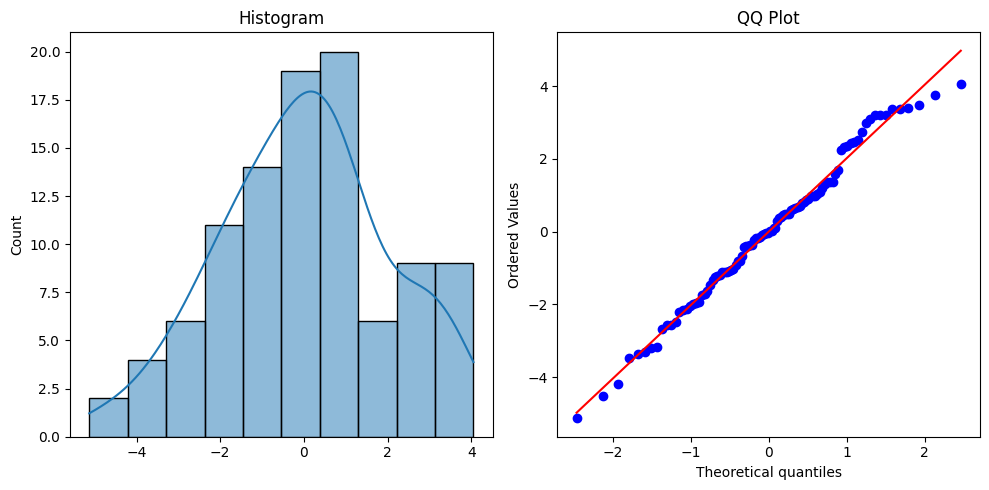

In [11]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Apa kesimpulan Anda berdasarkan plot di atas?

Dari histogram, residual terlihat cukup simetris dan sebagian nilainya berasa di sekitar 0. Pada QQ-Plot, sebagian besar titik juga mengikuti garis diagonal, meskipun ada beberapa titik yang sedkit menyimpang. Jadi, residual dapat dikatakan cukup mendekati distribusi normal dan asumsi normalitas secara umum terpenuhi.

In [12]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9866118181617785, p-value = 0.4120549625356543


Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?

Ya, kesimpulannya sama dengan hasil berdasarkan plot. Karena $p\text{-value}$ > 0.05, maka tidak tolak $H_0$. Artinya, tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal. Sehingga, residual dapat dianggap berdistribusi normal.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [13]:
# Menentukan parameter simulasi
np.random.seed(1045)
n_periods = 120
beta_0, beta_1, beta_2= 50 + 45, 0.5 * 45, 0.02 * 45
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

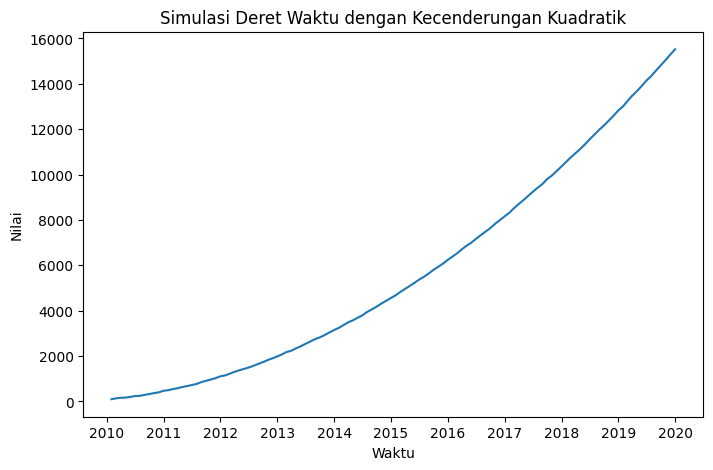

In [14]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?

Dari plot terlihat bahwa nilai deret terus meningkat seiring bertambahnya waktu. Namun, peningkatannya tidak konstan. Pada awal periode, kenaikan nilai masih relatif kecil, kemudian semakin lama kenaikannya semakin besar. Pola ini membentuk kurva yang semakin menanjak, sehingga menunjukkan adanya kecenderungan (tren) kuadratik.

Perbedaan utama dengan pola kecenderungan linear terletak pada bentuk kenaikan nilainya. Pada kecenderungan linear, nilai deret meningkat dengan laju yang relatif konstan sehingga grafik membentuk garis lurus. Sedangkan, pola kecenderungan kuadratik, laju peningkatan nilai semakin besar seiring waktu sehingga grafik membentuk kurva yang semakin menanjak.

In [15]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.244e+07
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.13e-312
Time:                        12:28:02   Log-Likelihood:                -446.09
No. Observations:                 120   AIC:                             898.2
Df Residuals:                     117   BIC:                             906.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         94.1129      2.717     34.641      0.0

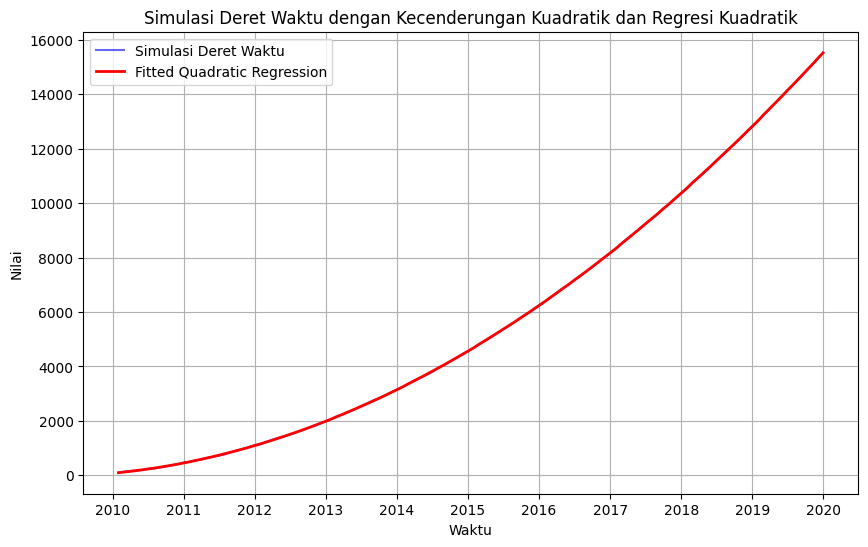

In [16]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!

Ya, asumsi-asumsi model diasumsikan terpenuhi



Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!

Model yang dipaskan sudah tepat untuk deret dengan kecenderungan kuadratik. Model yang digunakan berbentuk

$$
Y_t = \beta_0 + \beta_1t + \beta_2t^2 + \varepsilon_t
$$

Berdasarkan hasil estimasi, diperoleh model

$$
\hat{Y}_t = 94.1129 + 22.5263t + 0.9t^2
$$

Nilai parameter hasil estimasi cukup dekat dengan parameter asli yang digunakan dalam simulasi, yaitu

$$
\beta_0 = 94.1129,\quad \beta_1 = 22.5263,\quad \beta_2 = 0.9
$$

Selain itu, diperoleh nilai

$$
R^2 = 1.000
$$

yang menunjukkan bahwa model mampu menjelaskan hampir seluruh variasi nilai pada deret. Ketiga koefisien regresi juga signifikan secara statistik dengan

$$
p\text{-value} < 0.001
$$

Dengan demikian, model regresi kuadratik yang dipaskan sudah tepat dan mampu menggambarkan pola deret dengan sangat baik.

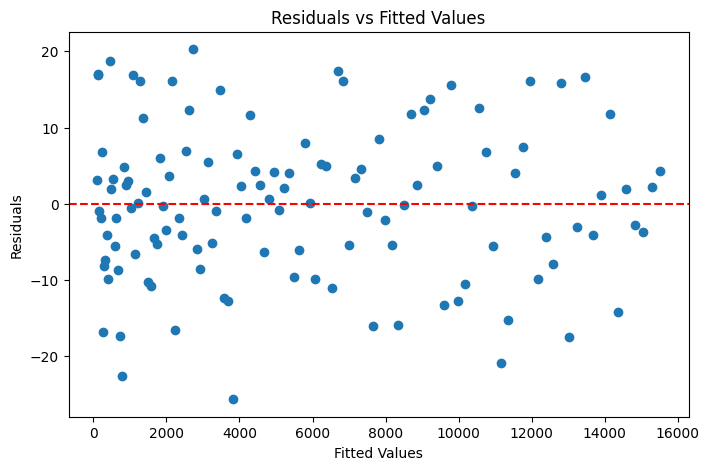

In [17]:
# cek asumsi model regresi kuadratik
# Plot Residual vs Fitted
import matplotlib.pyplot as plt

fitted = model_quad.fittedvalues
residuals = model_quad.resid

plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()

In [18]:
# Uji Breusch-Pagan
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    model_quad.resid,
    model_quad.model.exog
)

print(f"Breusch-Pagan Statistic: {bp_test[0]:.4f}")
print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")

Breusch-Pagan Statistic: 0.2616
P-value Breusch-Pagan Test: 0.8774


Berdasarkan plot Residuals vs Fitted Values, terlihat bahwa titik-titik residual tersebar di sekitar garis dan tidak membentuk pola tertentu. Hal ini menunjukkan bahwa varians residual cenderung konstan. Hasil in didukung oleh hasil yang diperoleh dari Uji Breusch-Pagan.
Hipotesis yang digunakan:

$H_0$ : Tidak terdapat hetereskedastisitas (residual bersifat homogen)

$H_1$ : Terdapat heteroskedastisitas

Dari uji Breusch-Pagan diperoleh nilai $p\text{-value}$ = 0.8774. Karena nilai > 0.05, maka tidak tolak $H_0$. Artinya, tidak ditemukan adanya cukup bukti heteroskedastisitas pada residual. Penyebaran atau varians residual dapat dianggap relatif konstan, sehingga asumsi homoskedastisitas terpenuhi.

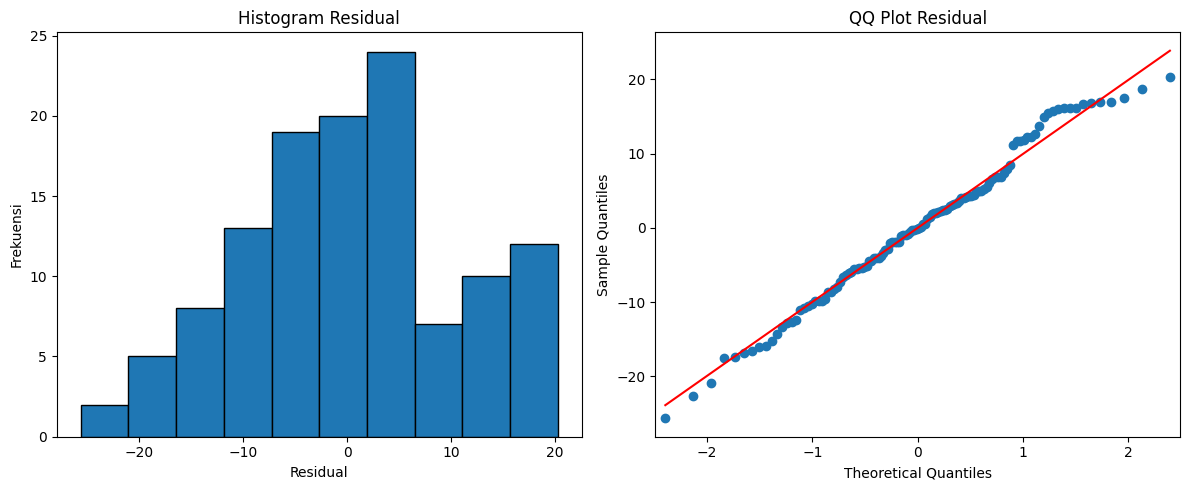

In [19]:
# Histogram & QQ-Plot
residuals = model_quad
import matplotlib.pyplot as plt
import statsmodels.api as sm

residuals = model_quad.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram residual
axes[0].hist(residuals, bins=10, edgecolor="black")
axes[0].set_title("Histogram Residual")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frekuensi")

# QQ Plot residual
sm.qqplot(residuals, line="s", ax=axes[1])
axes[1].set_title("QQ Plot Residual")

plt.tight_layout()
plt.show()

In [20]:
# Uji Shapiro-Wilk
from scipy.stats import shapiro

stat, p_value = shapiro(model_quad.resid)

print(f"Shapiro-Wilk Test: Statistics = {stat:.4f}, p-value = {p_value:.4f}")

Shapiro-Wilk Test: Statistics = 0.9852, p-value = 0.2135


Dari histogram residual, terlihat bahwa residual memiliki penyebaran yang cukup merupai bentuk distribusi normal dan berpusat di sekitar 0. Pada QQ-Plot, sebagian besar titik berada cukup dekat dengan garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian ekor. Hasil ini didukung oleh uji Shapiro-Wilk. Karena $p\text{-value}$ (0.2135) > 0.05, maka tidak tolak $H_0$. Artinya, tidak terdapat cukup bukti untuk menyatakan bahwa residual tidak berdistribusi normal. Sehingga, residual dapat dianggap berdistribusi normal.

<Figure size 800x500 with 0 Axes>

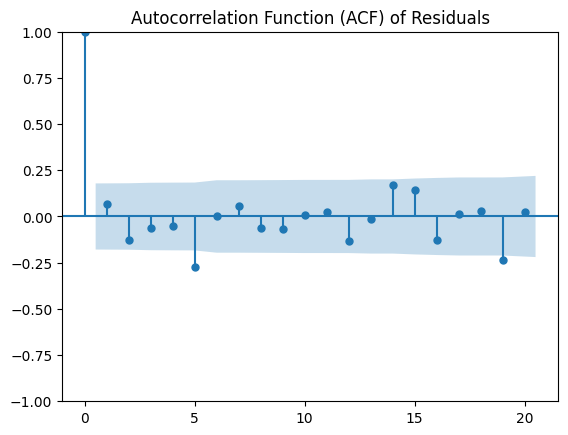

In [21]:
# Plot ACF Residual
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(8, 5))
plot_acf(model_quad.resid, lags=20)
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.show()

In [22]:
# Uji Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(
    model_quad.resid,
    lags=20,
    return_df=True
)

print(ljung_box)

      lb_stat  lb_pvalue
1    0.594837   0.440555
2    2.548949   0.279578
3    2.999751   0.391664
4    3.311569   0.507101
5   12.657210   0.026812
6   12.658949   0.048783
7   13.087312   0.070009
8   13.595616   0.092934
9   14.166003   0.116542
10  14.180786   0.164904
11  14.262000   0.218833
12  16.556131   0.167071
13  16.577510   0.219344
14  20.618412   0.111819
15  23.573333   0.072702
16  25.887041   0.055639
17  25.908562   0.076143
18  26.052332   0.098567
19  34.127054   0.017754
20  34.194929   0.024836


## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [23]:
# Menentukan parameter simulasi
np.random.seed(1045)
n_periods = 120
beta0, beta1, beta2=50 + 45,-25 * 45, -2 * 45
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


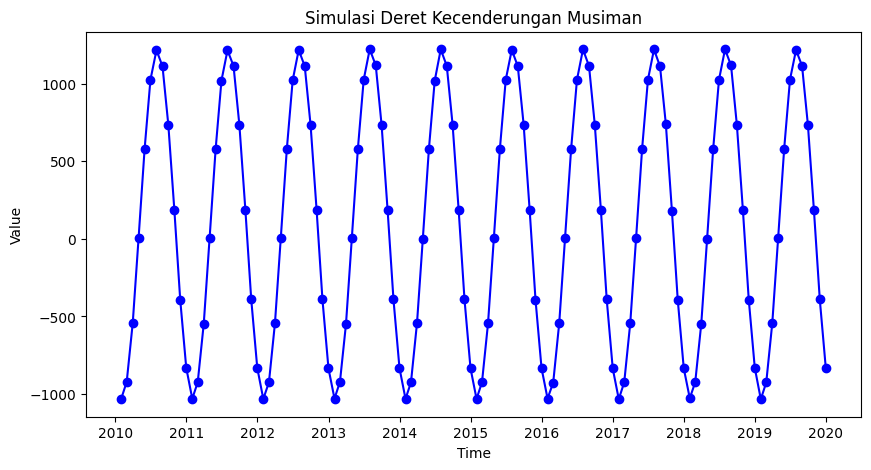

In [24]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?

Deret tersebut menunjukkan pola musiman dengan periode 12. Terlihat bahwa nilai deret naik dan turun secara berulang dengan pola yang hampir sama setiap 12 periode. Nilai mencapai titik tinggi dan rendah secara berulang sehingga menunjukkan adanya pola yang berulang setiap 12 bulan. Nilai pada suatu bulan cenderung memiliki pola yang mirip dengan bulan yang sama pada tahun berikutnya. Pola tersebut berlangsung relatif konsisten dari tahun 2010 hingga 2020. Jadi, deret dapat dikatakan memiliki pola musiman dengan periode 12, yang berarti pola berulang setiap tahun atau 12 bulan.

In [25]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [26]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [27]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [28]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.776e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.87e-278
Time:                        12:31:29   Log-Likelihood:                -245.75
No. Observations:                 120   AIC:                             515.5
Df Residuals:                     108   BIC:                             548.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari    -1030.4018      0.625  -1648.098      0.0

Bagaimana interpretasi dari hasil tersebut?

Hasil regresi menunjukkan bahwa model dengan komponen musiman periode 12 mampu menggambarkan pola deret dengan sangat baik. Hal ini terlihat dari nilai $R^2=1$, yang menunjukkan bahwa sekitar $100\%$ variasi nilai deret dapat dijelaskan oleh pola musiman dalam model.

Seluruh koefisien bulan Januari hingga Desember memiliki $p\text{-value}<0.001$. Hal ini menunjukkan bahwa setiap bulan memberikan kontribusi yang signifikan terhadap pola musiman pada deret.

Berdasarkan nilai koefisien, nilai deret meningkat hingga mencapai nilai tertinggi pada bulan Juli, yaitu sekitar $1219.3645$. Setelah itu, nilai deret cenderung menurun hingga mencapai nilai terendah pada bulan Januari, yaitu sekitar $-1030.4018$.

Nilai $F$-statistic sebesar $1.776e+06$ dengan $p\text{-value}<0.001$ menunjukkan bahwa model secara keseluruhan signifikan.

Dengan demikian, model regresi yang digunakan sudah sangat baik dalam menggambarkan pola musiman dengan periode $12$. Pola nilai deret menunjukkan adanya pola yang berulang setiap $12$ bulan dengan variasi nilai yang sebagian besar dapat dijelaskan oleh komponen musiman.

In [29]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

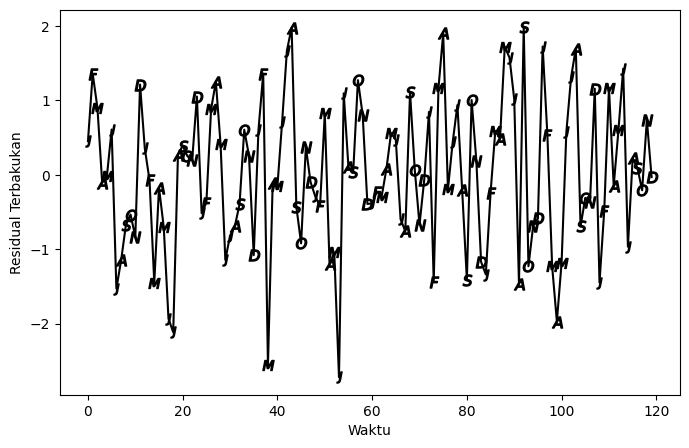

In [30]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


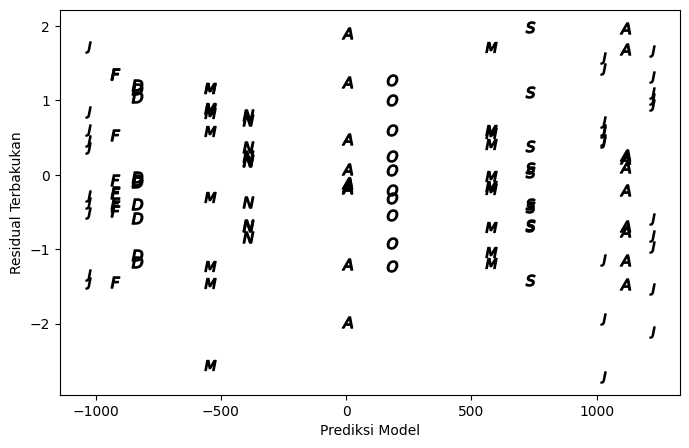

In [31]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

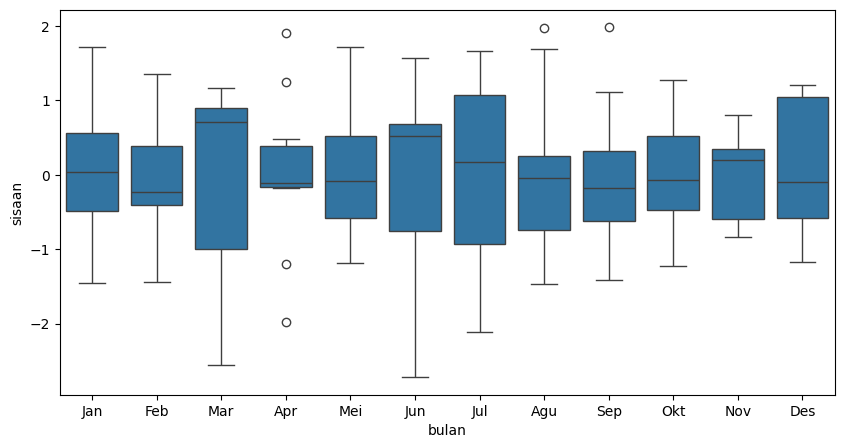

In [32]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

Bagaimana interpretasi Anda terhadap tiga plot di atas?



*   (Residual terhadap waktu)
Pada plot pertama, residual terlihat berfluktuasi di sekitar nilai 0 dari awal hingga akhir periode. Tidak terlihat adanya pola naik, turun, atau pola berulang yang sangat jelas. Artinya, residual secara umum tidak menunjukkan pola sistematis terhadap waktu.
*   (Residual terhadap prediksi model)
Pada plot kedua, reidual tersebar di sekitar 0 pada berbagai nilai prediksi model. Tidak terlihat pola tertentu seperti residual yang semakin besar ketika nilai prediksi semakin besar. Hal ini menunjukkan bahwa tidak ada pola yang jelas antara residual dan nilai prediksi model
*   (Boxplot residual berdasarkan bulan) Pada plot ketiga, median residual sebagian besar bulan berada cukup dekat dengan 0. Penyebaran residual memang berbeda-beda antarbulan dan terhadap beberapa outlier, terutama pada beberapa bulan seperti April, Agustus, dan September. Namun, tidak terlihat pola musiman yang kuat pada residual.

Secara keseluruhan, ketiga plot menunjukkan bahwa residul cenderung tersebar di sekitar 0 dan tidak menunjukkan pola sistematis yang kuat terhadap waktu maupun hasil prediksi model. Meskipun terdapat beberapa outlier dan perbedaan penyebaran residual antarbulan, pola residual secara umum sudah cukup acak.Hal ini menunjukkan bahwa model musiman periode 12 sudah cukup baik dalam menangkap pola musiman pada deret.





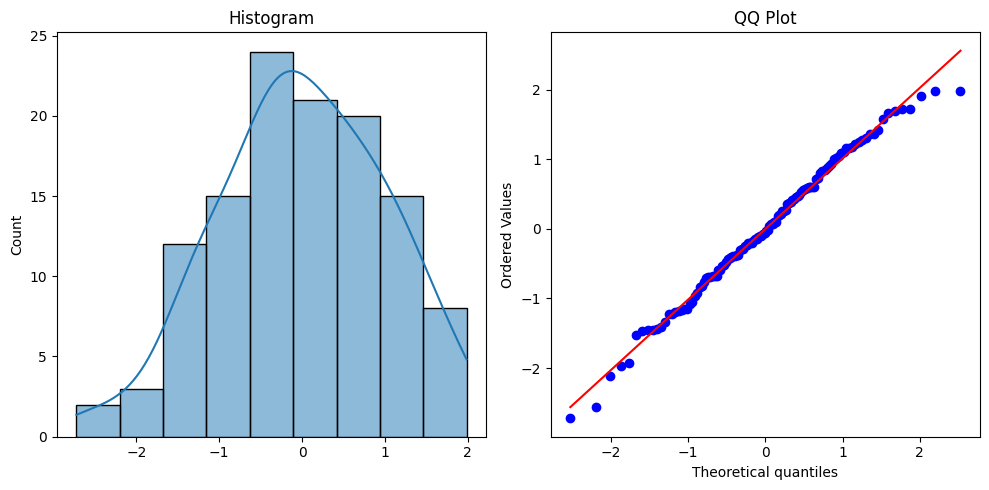

In [33]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?

Ya, berdasarkan histogram dan QQ-Plot tersebut, model yang dipaskan dapat dikatakan sudah cukup tepat , khususnya dari sisi asumsi normalitas residual.

Histogram menunjukkan bahwa residual memiliki bentuk yang cukup menyerupai distribusi normal dan berpusat di sekitar 0. Pada QQ-Plot, sebagian besar titik berada dekat dengan garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian atas.

Jadi, tidak terlihat penyimpangan yang besar dari distribusi normal pada residual. Sehingga, berdasarkan kedua plot tersebut asumsi normalitas residual dapat dianggap terpenuhi dan model yang dipaskan sudah cukup baik.

Hitunglah statistik uji untuk mengecek asumsi model

In [35]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep
residuals = musiman.resid
fitted = musiman.fittedvalues

# Uji Shapiro-Wilk
from scipy.stats import shapiro

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk Statistic :", round(stat, 4))
print("P-value Shapiro-Wilk   :", round(p_value, 4))

if p_value > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")

Shapiro-Wilk Statistic : 0.9897
P-value Shapiro-Wilk   : 0.5061
Kesimpulan: Residual berdistribusi normal.


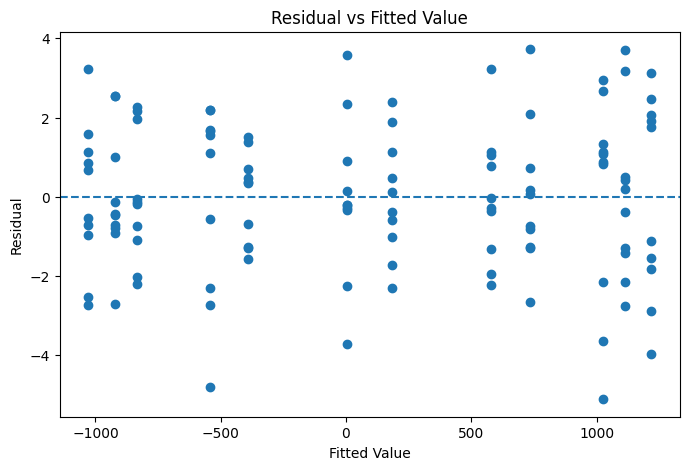

In [36]:
#Residual vs Fitted
plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Fitted Value')
plt.ylabel('Residual')
plt.title('Residual vs Fitted Value')
plt.show()

In [39]:
# Uji Breusch-Pagan
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Residual dan fitted value
residuals = musiman.resid
fitted = musiman.fittedvalues

# Hipotesis
print("UJI BREUSCH-PAGAN")
print("H0 : Tidak terdapat heteroskedastisitas (varians residual konstan)")
print("H1 : Terdapat heteroskedastisitas (varians residual tidak konstan)")
print("Taraf signifikansi = 0.05")

# Matriks untuk uji
X_bp = sm.add_constant(fitted)

# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, X_bp)

lm_stat = bp_test[0]
lm_pvalue = bp_test[1]
f_stat = bp_test[2]
f_pvalue = bp_test[3]

print("\nHasil Uji Breusch-Pagan")
print("LM Statistic :", round(lm_stat, 4))
print("LM P-value   :", round(lm_pvalue, 4))
print("F Statistic  :", round(f_stat, 4))
print("F P-value    :", round(f_pvalue, 4))

# Keputusan
if lm_pvalue > 0.05:
    print("\nKeputusan : Gagal menolak H0")
    print("Kesimpulan : Tidak terdapat heteroskedastisitas.")
else:
    print("\nKeputusan : Tolak H0")
    print("Kesimpulan : Terdapat heteroskedastisitas.")

UJI BREUSCH-PAGAN
H0 : Tidak terdapat heteroskedastisitas (varians residual konstan)
H1 : Terdapat heteroskedastisitas (varians residual tidak konstan)
Taraf signifikansi = 0.05

Hasil Uji Breusch-Pagan
LM Statistic : 3.4804
LM P-value   : 0.0621
F Statistic  : 3.5246
F P-value    : 0.0629

Keputusan : Gagal menolak H0
Kesimpulan : Tidak terdapat heteroskedastisitas.


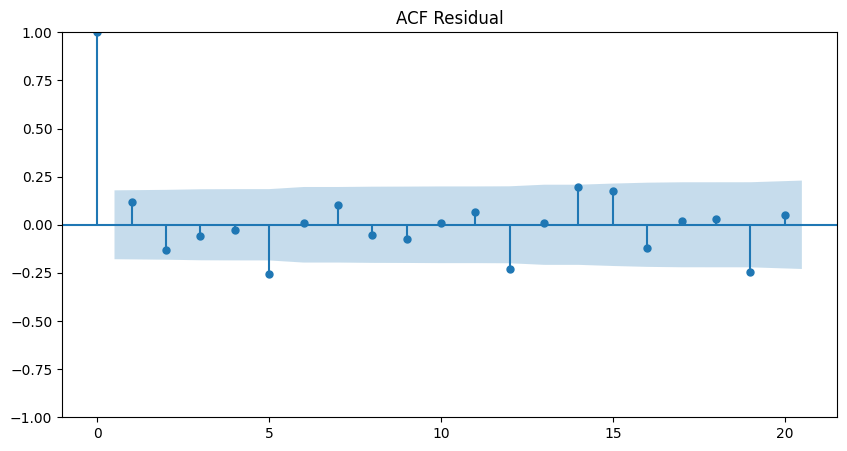

In [40]:
# ACF Residual
plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=20, ax=plt.gca())
plt.title('ACF Residual')
plt.show()

In [43]:
# Uji Ljung-Box
ljung_box = acorr_ljungbox(
    residuals,
    lags=20,
    return_df=True
)


print("\nUji Ljung-Box:")
for lag, pvalue in zip(ljung_box.index, ljung_box['lb_pvalue']):
    if pvalue > 0.05:
        print(f"Lag {lag}: p-value = {pvalue:.4f} -> Tidak ada autokorelasi")
    else:
        print(f"Lag {lag}: p-value = {pvalue:.4f} -> Ada autokorelasi")


Uji Ljung-Box:
Lag 1: p-value = 0.1845 -> Tidak ada autokorelasi
Lag 2: p-value = 0.1422 -> Tidak ada autokorelasi
Lag 3: p-value = 0.2260 -> Tidak ada autokorelasi
Lag 4: p-value = 0.3487 -> Tidak ada autokorelasi
Lag 5: p-value = 0.0251 -> Ada autokorelasi
Lag 6: p-value = 0.0458 -> Ada autokorelasi
Lag 7: p-value = 0.0488 -> Ada autokorelasi
Lag 8: p-value = 0.0687 -> Tidak ada autokorelasi
Lag 9: p-value = 0.0853 -> Tidak ada autokorelasi
Lag 10: p-value = 0.1240 -> Tidak ada autokorelasi
Lag 11: p-value = 0.1487 -> Tidak ada autokorelasi
Lag 12: p-value = 0.0285 -> Ada autokorelasi
Lag 13: p-value = 0.0426 -> Ada autokorelasi
Lag 14: p-value = 0.0129 -> Ada autokorelasi
Lag 15: p-value = 0.0052 -> Ada autokorelasi
Lag 16: p-value = 0.0044 -> Ada autokorelasi
Lag 17: p-value = 0.0067 -> Ada autokorelasi
Lag 18: p-value = 0.0099 -> Ada autokorelasi
Lag 19: p-value = 0.0010 -> Ada autokorelasi
Lag 20: p-value = 0.0015 -> Ada autokorelasi


In [44]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [46]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.776e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.87e-278
Time:                        12:54:23   Log-Likelihood:                -245.75
No. Observations:                 120   AIC:                             515.5
Df Residuals:                     108   BIC:                             548.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1030.4018      0.625  -1648.098      0.0

Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!

Berdasarkan hasil pengepasan model dengan intersep, diperoleh model regresi musiman dengan Januari sebagai kategori acuan. Model tersebut dapat dituliskan sebagai

$Y_t = \beta_0 + \beta_2D_{\text{Feb}} + \beta_3D_{\text{Mar}} + \cdots + \beta_{12}D_{\text{Des}} + \varepsilon_t$.


Nilai intersep yang diperoleh adalah $\hat{\beta}_0 = -1030.4018$. Nilai tersebut menunjukkan rata-rata nilai deret pada bulan Januari. Sementara itu, koefisien untuk bulan lainnya menunjukkan perbedaan rata-rata nilai bulan tersebut terhadap bulan Januari.

Sebagai contoh, koefisien bulan Februari sebesar $\hat{\beta}_{\text{Feb}} = 106.8051$.

Jika dibandingkan dengan model tanpa intersep, kedua model memberikan pola musiman yang sama. Perbedaannya terletak pada cara interpretasi koefisien. Pada model tanpa intersep, koefisien setiap bulan langsung menunjukkan rata-rata nilai pada bulan tersebut. Sementara itu, pada model dengan intersep, intersep menunjukkan rata-rata bulan Januari sebagai kategori acuan, sedangkan koefisien bulan lainnya menunjukkan selisih rata-rata bulan tersebut terhadap Januari.

Apakah model dengan intersep sudah memenuhi asumsi regresi?

Berdasarkan uji Shapiro-Wilk diperoleh statistik sebesar $0.9897$ dengan $p\text{-value}=0.5061$. Karena $p\text{-value}>0.05$, maka $H_0$ tidak ditolak, sehingga dapat disimpulkan bahwa residual model berdistribusi normal. Hal ini juga didukung oleh histogram yang menunjukkan bentuk distribusi yang mendekati normal serta QQ plot yang sebagian besar titiknya mengikuti garis diagonal. Dengan demikian, asumsi normalitas residual pada model musiman dengan intersep terpenuhi.

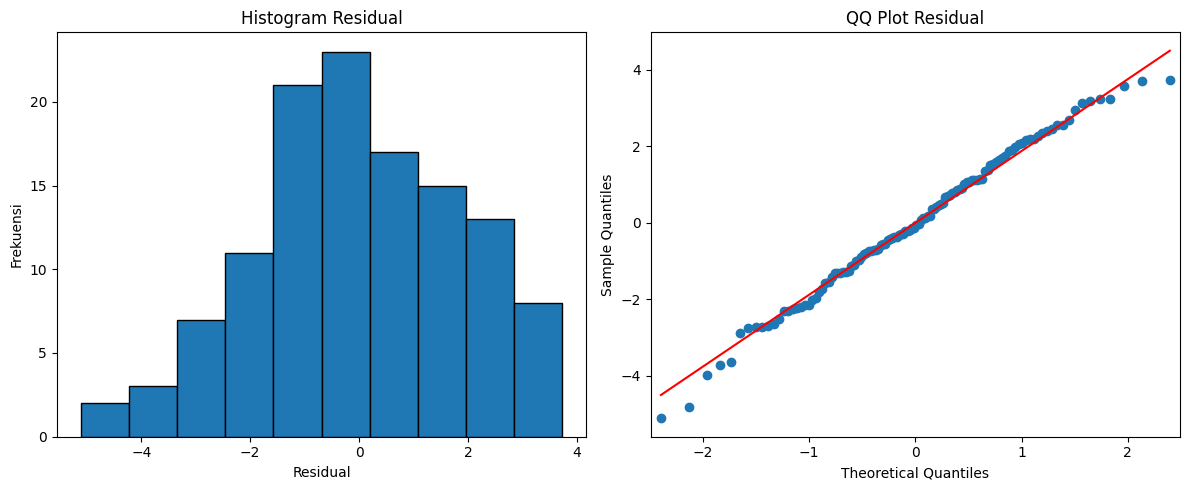

In [58]:
# uji asumsi model dengan intersep
# Histogram & QQ-Plot
import matplotlib.pyplot as plt
import statsmodels.api as sm

residuals = musiman.resid

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram residual
axes[0].hist(residuals, bins=10, edgecolor="black")
axes[0].set_title("Histogram Residual")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Frekuensi")

# QQ Plot
sm.qqplot(residuals, line="s", ax=axes[1])
axes[1].set_title("QQ Plot Residual")

plt.tight_layout()
plt.show()

In [59]:
# Uji Shapiro-Wilk
from scipy.stats import shapiro

stat, p_value = shapiro(residuals)

print("Shapiro-Wilk Statistic :", round(stat, 4))
print("P-value Shapiro-Wilk   :", round(p_value, 4))

if p_value > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")

Shapiro-Wilk Statistic : 0.9897
P-value Shapiro-Wilk   : 0.5061
Kesimpulan: Residual berdistribusi normal.


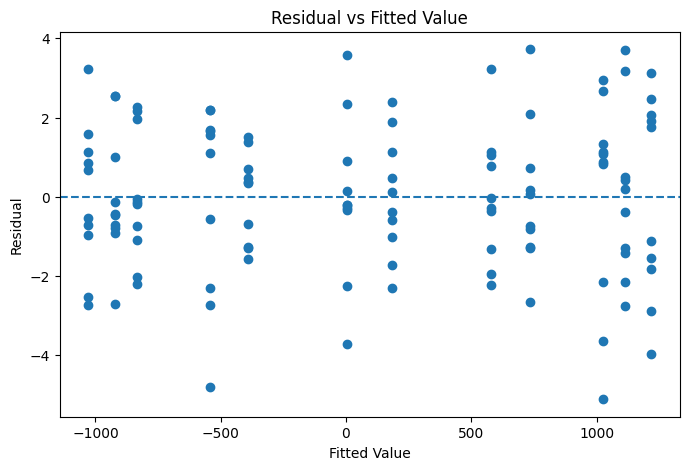

In [60]:
#Residual vs Fitted
plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Fitted Value')
plt.ylabel('Residual')
plt.title('Residual vs Fitted Value')
plt.show()

In [61]:
# Uji Breusch-Pagan
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Residual dan fitted value
residuals = musiman.resid
fitted = musiman.fittedvalues

# Hipotesis
print("UJI BREUSCH-PAGAN")
print("H0 : Tidak terdapat heteroskedastisitas (varians residual konstan)")
print("H1 : Terdapat heteroskedastisitas (varians residual tidak konstan)")
print("Taraf signifikansi = 0.05")

# Matriks untuk uji
X_bp = sm.add_constant(fitted)

# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, X_bp)

lm_stat = bp_test[0]
lm_pvalue = bp_test[1]
f_stat = bp_test[2]
f_pvalue = bp_test[3]

print("\nHasil Uji Breusch-Pagan")
print("LM Statistic :", round(lm_stat, 4))
print("LM P-value   :", round(lm_pvalue, 4))
print("F Statistic  :", round(f_stat, 4))
print("F P-value    :", round(f_pvalue, 4))

# Keputusan
if lm_pvalue > 0.05:
    print("\nKeputusan : Gagal menolak H0")
    print("Kesimpulan : Tidak terdapat heteroskedastisitas.")
else:
    print("\nKeputusan : Tolak H0")
    print("Kesimpulan : Terdapat heteroskedastisitas.")

UJI BREUSCH-PAGAN
H0 : Tidak terdapat heteroskedastisitas (varians residual konstan)
H1 : Terdapat heteroskedastisitas (varians residual tidak konstan)
Taraf signifikansi = 0.05

Hasil Uji Breusch-Pagan
LM Statistic : 3.4804
LM P-value   : 0.0621
F Statistic  : 3.5246
F P-value    : 0.0629

Keputusan : Gagal menolak H0
Kesimpulan : Tidak terdapat heteroskedastisitas.


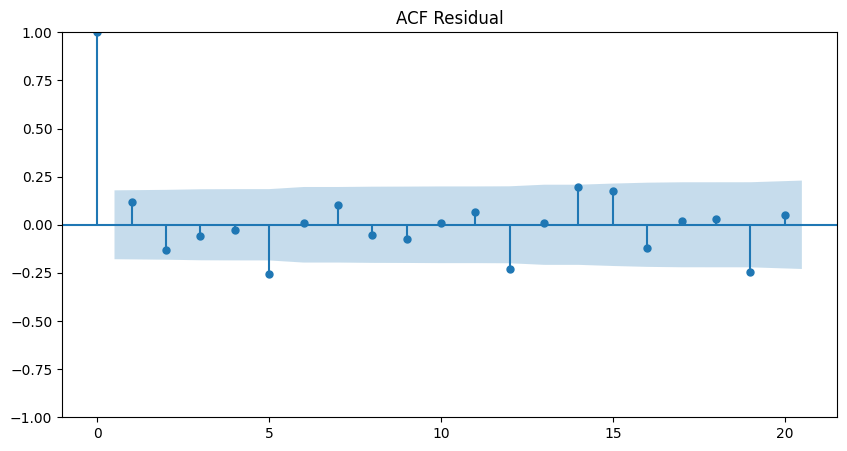

In [62]:
# ACF Residual
plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=20, ax=plt.gca())
plt.title('ACF Residual')
plt.show()

In [63]:
# Uji Ljung-Box
ljung_box = acorr_ljungbox(
    residuals,
    lags=20,
    return_df=True
)


print("\nUji Ljung-Box:")
for lag, pvalue in zip(ljung_box.index, ljung_box['lb_pvalue']):
    if pvalue > 0.05:
        print(f"Lag {lag}: p-value = {pvalue:.4f} -> Tidak ada autokorelasi")
    else:
        print(f"Lag {lag}: p-value = {pvalue:.4f} -> Ada autokorelasi")


Uji Ljung-Box:
Lag 1: p-value = 0.1845 -> Tidak ada autokorelasi
Lag 2: p-value = 0.1422 -> Tidak ada autokorelasi
Lag 3: p-value = 0.2260 -> Tidak ada autokorelasi
Lag 4: p-value = 0.3487 -> Tidak ada autokorelasi
Lag 5: p-value = 0.0251 -> Ada autokorelasi
Lag 6: p-value = 0.0458 -> Ada autokorelasi
Lag 7: p-value = 0.0488 -> Ada autokorelasi
Lag 8: p-value = 0.0687 -> Tidak ada autokorelasi
Lag 9: p-value = 0.0853 -> Tidak ada autokorelasi
Lag 10: p-value = 0.1240 -> Tidak ada autokorelasi
Lag 11: p-value = 0.1487 -> Tidak ada autokorelasi
Lag 12: p-value = 0.0285 -> Ada autokorelasi
Lag 13: p-value = 0.0426 -> Ada autokorelasi
Lag 14: p-value = 0.0129 -> Ada autokorelasi
Lag 15: p-value = 0.0052 -> Ada autokorelasi
Lag 16: p-value = 0.0044 -> Ada autokorelasi
Lag 17: p-value = 0.0067 -> Ada autokorelasi
Lag 18: p-value = 0.0099 -> Ada autokorelasi
Lag 19: p-value = 0.0010 -> Ada autokorelasi
Lag 20: p-value = 0.0015 -> Ada autokorelasi


## Kecenderungan Linear dan Musiman

In [64]:
# Parameter
np.random.seed(1045)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5 * 45, 10 * 45 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


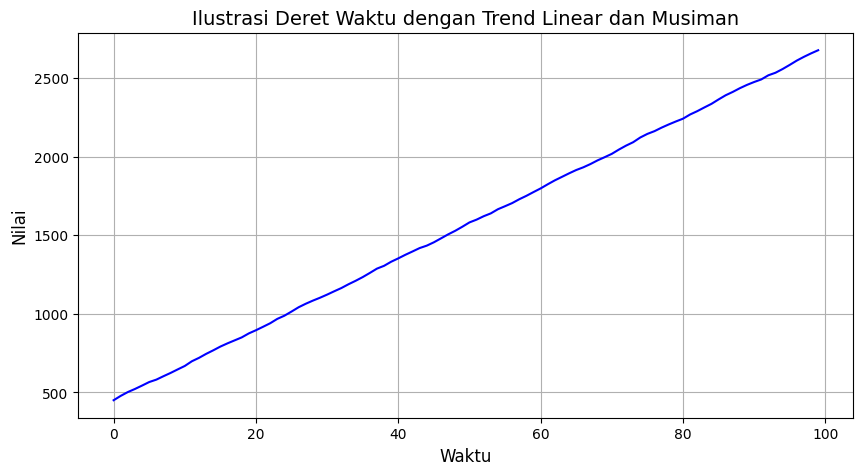

In [65]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [66]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [67]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [68]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 8.547e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          4.44e-215
Time:                        13:07:41   Log-Likelihood:                -205.64
No. Observations:                 100   AIC:                             437.3
Df Residuals:                      87   BIC:                             471.2
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      449.6789      0.756    594.935      0.0

Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?

Hasil estimasi menunjukkan bahwa koefisien regresi untuk setiap bulan menggambarkan tingkat dasar variabel respons pada masing-masing bulan ketika $period=0$, karena model tidak menggunakan intersep. Nilai koefisien terbesar terdapat pada bulan Maret sebesar $455.3693$, sedangkan nilai terkecil terdapat pada bulan November sebesar $444.8153$, yang menunjukkan adanya pola musiman dalam data. Sementara itu, koefisien period sebesar $22.5046$ menunjukkan bahwa setiap peningkatan satu periode waktu diperkirakan meningkatkan nilai respons sebesar $22.5046$ satuan. Koefisien tersebut signifikan secara statistik dengan $p\text{-value}<0.05$, sehingga terdapat bukti adanya tren peningkatan dari waktu ke waktu.

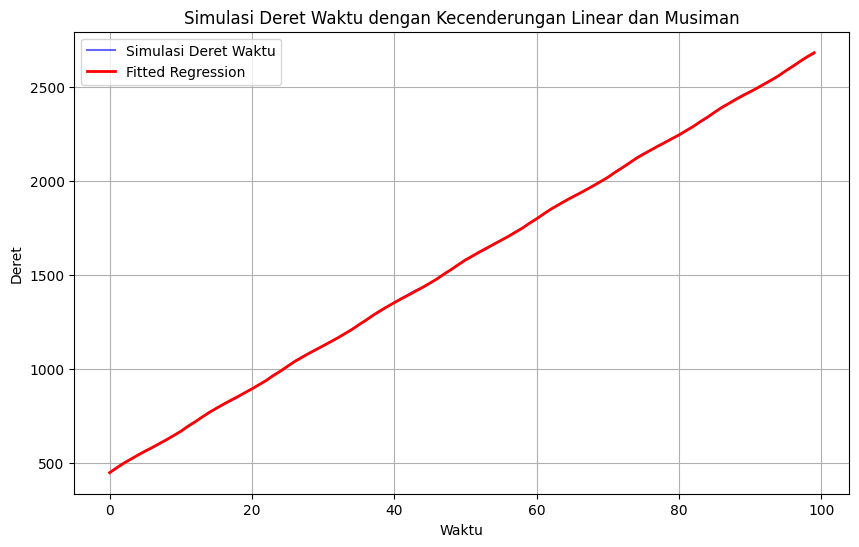

In [69]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!

In [72]:
# uji asumsi model
residuals = model_mix.resid
fitted = model_mix.fittedvalues

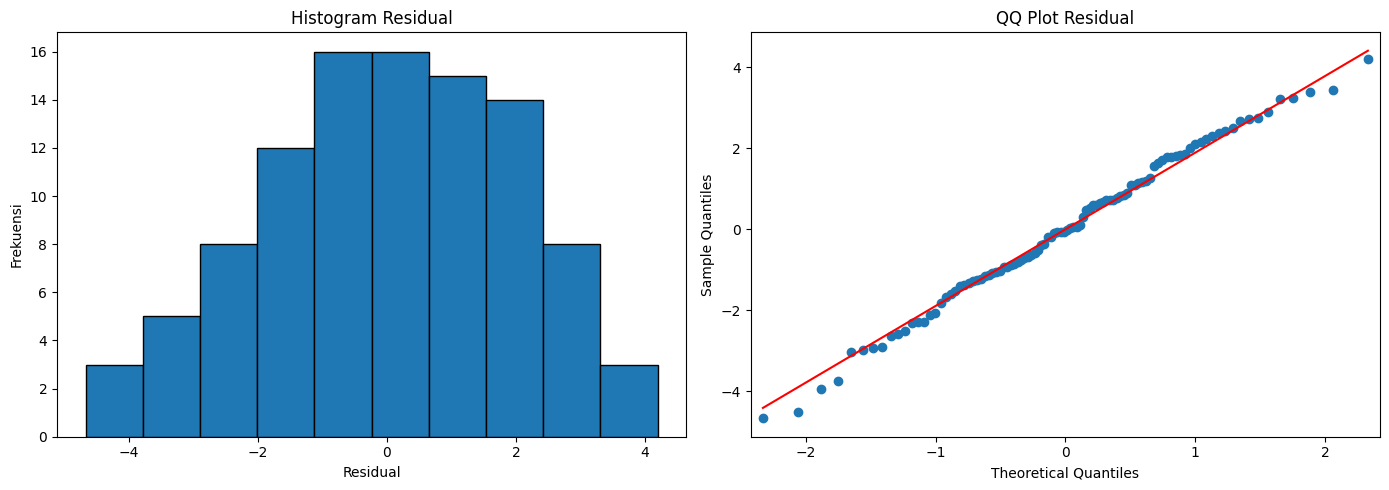

In [73]:
# Histogram dan QQ Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram residual
axes[0].hist(residuals, bins=10, edgecolor='black')
axes[0].set_title('Histogram Residual')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frekuensi')

# QQ Plot
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('QQ Plot Residual')

plt.tight_layout()
plt.show()

In [75]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p = shapiro(residuals)

print("Shapiro-Wilk Statistic :", round(shapiro_stat, 4))
print("P-value Shapiro-Wilk   :", round(shapiro_p, 4))

if shapiro_p > 0.05:
    print("Kesimpulan: Residual berdistribusi normal.")
else:
    print("Kesimpulan: Residual tidak berdistribusi normal.")

Shapiro-Wilk Statistic : 0.9906
P-value Shapiro-Wilk   : 0.7096
Kesimpulan: Residual berdistribusi normal.


In [77]:
# Uji Breusch-Pagan
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan

# Residual dan fitted value
residuals = model_mix.resid
fitted = model_mix.fittedvalues

# Hipotesis
print("UJI BREUSCH-PAGAN")
print("H0 : Tidak terdapat heteroskedastisitas (varians residual konstan)")
print("H1 : Terdapat heteroskedastisitas (varians residual tidak konstan)")
print("Taraf signifikansi = 0.05")

# Matriks untuk uji
X_bp = sm.add_constant(fitted)

# Breusch-Pagan Test
bp_test = het_breuschpagan(residuals, X_bp)

lm_stat = bp_test[0]
lm_pvalue = bp_test[1]
f_stat = bp_test[2]
f_pvalue = bp_test[3]

print("\nHasil Uji Breusch-Pagan")
print("LM Statistic :", round(lm_stat, 4))
print("LM P-value   :", round(lm_pvalue, 4))
print("F Statistic  :", round(f_stat, 4))
print("F P-value    :", round(f_pvalue, 4))

# Keputusan
if lm_pvalue > 0.05:
    print("\nKeputusan : Gagal menolak H0")
    print("Kesimpulan : Tidak terdapat heteroskedastisitas.")
else:
    print("\nKeputusan : Tolak H0")
    print("Kesimpulan : Terdapat heteroskedastisitas.")

UJI BREUSCH-PAGAN
H0 : Tidak terdapat heteroskedastisitas (varians residual konstan)
H1 : Terdapat heteroskedastisitas (varians residual tidak konstan)
Taraf signifikansi = 0.05

Hasil Uji Breusch-Pagan
LM Statistic : 1.6507
LM P-value   : 0.1989
F Statistic  : 1.6448
F P-value    : 0.2027

Keputusan : Gagal menolak H0
Kesimpulan : Tidak terdapat heteroskedastisitas.


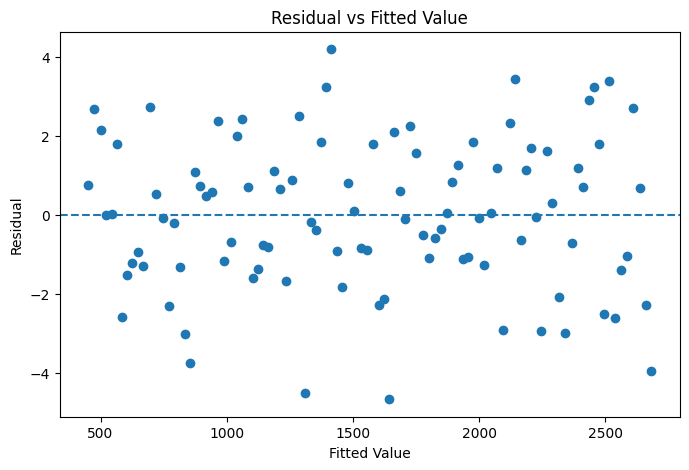

In [78]:
#Residual vs Fitted
plt.figure(figsize=(8, 5))
plt.scatter(fitted, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel('Fitted Value')
plt.ylabel('Residual')
plt.title('Residual vs Fitted Value')
plt.show()


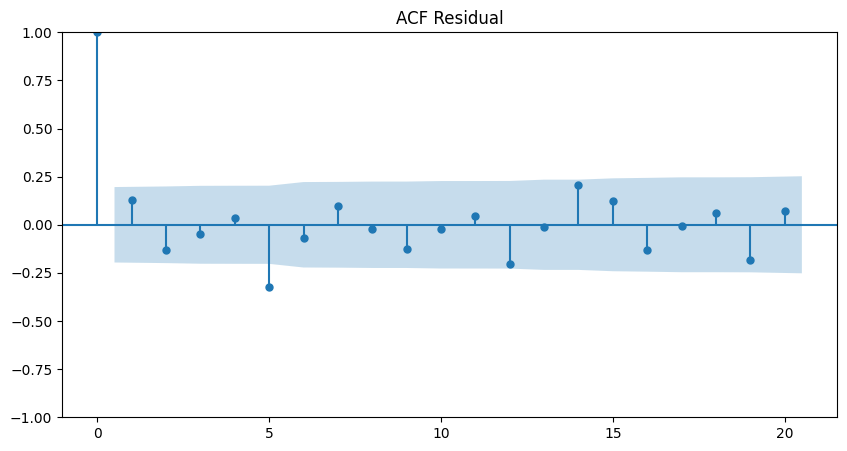

In [79]:
# ACF Residual
plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=20, ax=plt.gca())
plt.title('ACF Residual')
plt.show()

In [81]:
# Uji Ljung-Box
ljung_box = acorr_ljungbox(
    residuals,
    lags=20,
    return_df=True
)


print("\nUji Ljung-Box:")
for lag, pvalue in zip(ljung_box.index, ljung_box['lb_pvalue']):
    if pvalue > 0.05:
        print(f"Lag {lag}: p-value = {pvalue:.4f} -> Tidak ada autokorelasi")
    else:
        print(f"Lag {lag}: p-value = {pvalue:.4f} -> Ada autokorelasi")


Uji Ljung-Box:
Lag 1: p-value = 0.1962 -> Tidak ada autokorelasi
Lag 2: p-value = 0.1805 -> Tidak ada autokorelasi
Lag 3: p-value = 0.3026 -> Tidak ada autokorelasi
Lag 4: p-value = 0.4374 -> Tidak ada autokorelasi
Lag 5: p-value = 0.0102 -> Ada autokorelasi
Lag 6: p-value = 0.0165 -> Ada autokorelasi
Lag 7: p-value = 0.0202 -> Ada autokorelasi
Lag 8: p-value = 0.0341 -> Ada autokorelasi
Lag 9: p-value = 0.0305 -> Ada autokorelasi
Lag 10: p-value = 0.0472 -> Ada autokorelasi
Lag 11: p-value = 0.0662 -> Tidak ada autokorelasi
Lag 12: p-value = 0.0243 -> Ada autokorelasi
Lag 13: p-value = 0.0366 -> Ada autokorelasi
Lag 14: p-value = 0.0122 -> Ada autokorelasi
Lag 15: p-value = 0.0108 -> Ada autokorelasi
Lag 16: p-value = 0.0087 -> Ada autokorelasi
Lag 17: p-value = 0.0132 -> Ada autokorelasi
Lag 18: p-value = 0.0172 -> Ada autokorelasi
Lag 19: p-value = 0.0077 -> Ada autokorelasi
Lag 20: p-value = 0.0095 -> Ada autokorelasi


Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [82]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

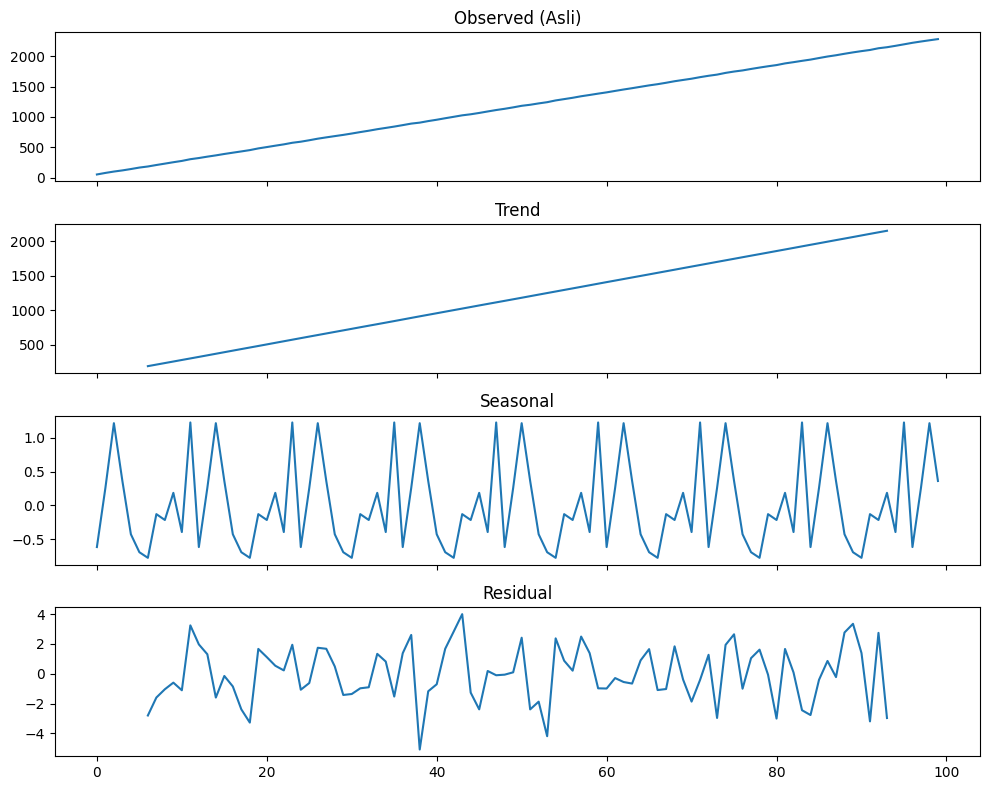

In [83]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi, deret waktu terdiri atas komponen trend yang menunjukkan peningkatan secara konsisten, komponen seasonal yang menunjukkan pola berulang secara periodik, serta komponen residual yang berfluktuasi di sekitar nol. Dominasi komponen trend menunjukkan bahwa perubahan jangka panjang merupakan faktor utama yang memengaruhi pergerakan deret, sedangkan komponen seasonal menunjukkan adanya pola musiman yang berulang. Residual yang relatif acak menunjukkan bahwa sebagian besar pola sistematis dalam deret telah dijelaskan oleh komponen trend dan seasonal.

In [84]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

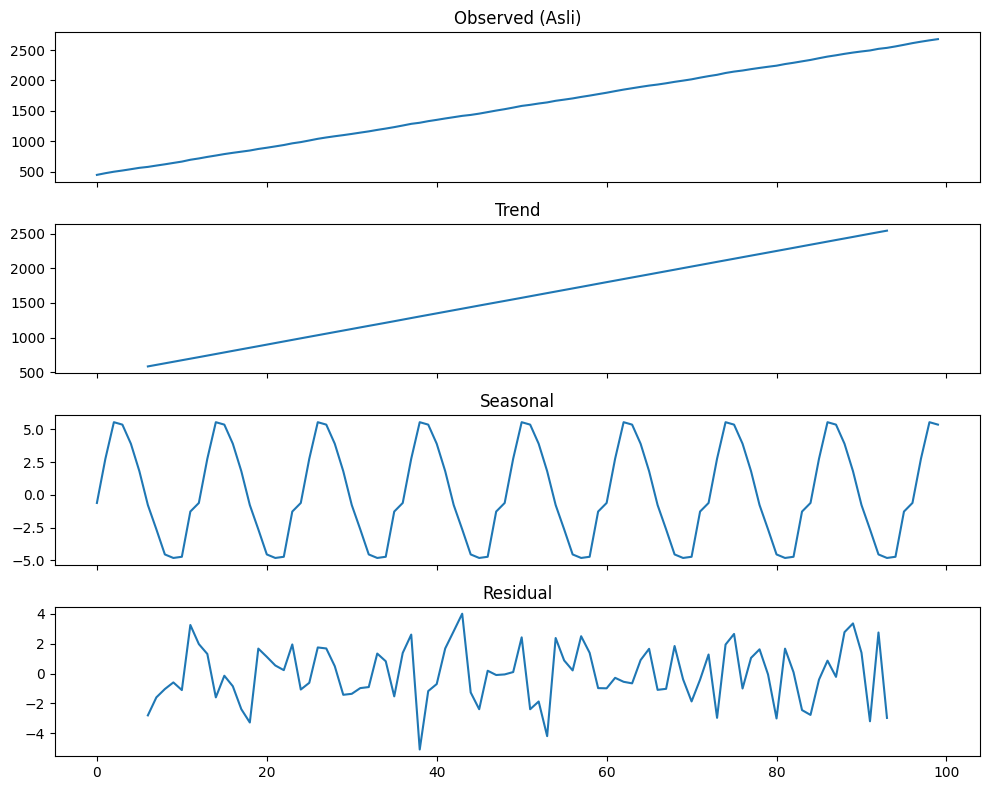

In [85]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


Bagaimana interpretasi hasil dekomposisi deret tersebut?

Berdasarkan hasil dekomposisi, deret waktu memiliki tren meningkat yang konsisten dan pola musiman yang kuat serta berulang secara teratur. Komponen trend menunjukkan adanya peningkatan jangka panjang, sedangkan komponen seasonal menunjukkan fluktuasi periodik dengan pola yang relatif konsisten pada setiap siklus. Setelah pengaruh trend dan seasonal dihilangkan, residual berfluktuasi di sekitar nol tanpa menunjukkan pola sistematis yang jelas. Dengan demikian, pergerakan utama deret waktu dapat dijelaskan dengan baik oleh komponen trend dan seasonal, sementara residual merepresentasikan variasi acak yang tidak dapat dijelaskan oleh kedua komponen tersebut.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [86]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1045)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05 * 45, 10 * 45 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

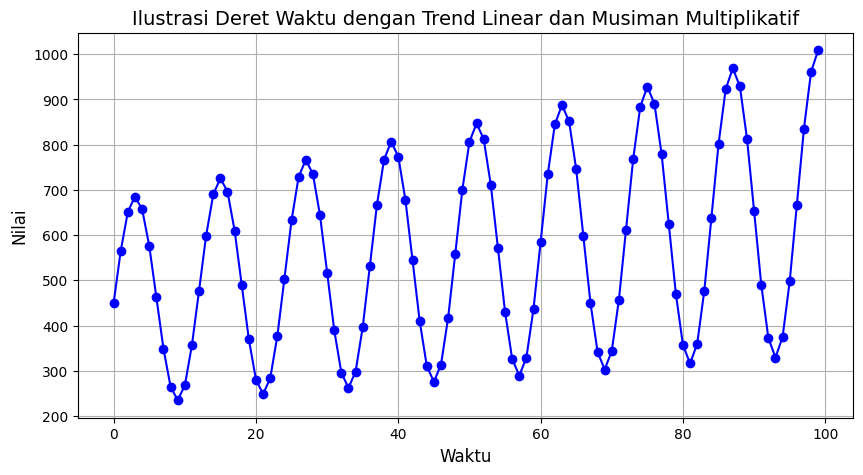

In [87]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [88]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

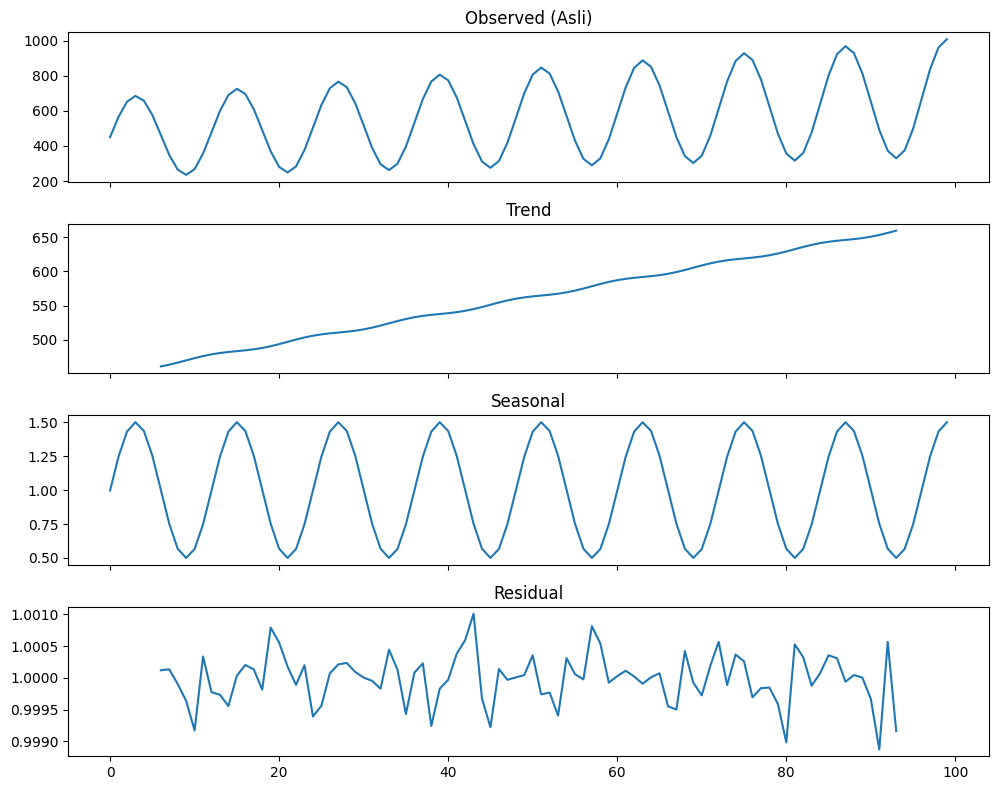

In [89]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?

Berdasarkan hasil dekomposisi, deret waktu menunjukkan adanya tren meningkat secara bertahap dan pola musiman yang kuat serta konsisten. Komponen trend meningkat dari sekitar 10,3 menjadi 14,7, sedangkan komponen seasonal menunjukkan pola berulang dengan bentuk yang relatif sama pada setiap siklus. Residual berfluktuasi di sekitar nilai 1 dengan variasi yang relatif kecil, sehingga menunjukkan bahwa sebagian besar pola dalam deret telah dapat dijelaskan oleh komponen trend dan seasonal. Hasil ini mengindikasikan bahwa model dekomposisi multiplikatif cukup sesuai untuk menggambarkan karakteristik deret tersebut.

In [90]:
# Parameter
np.random.seed(1045)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

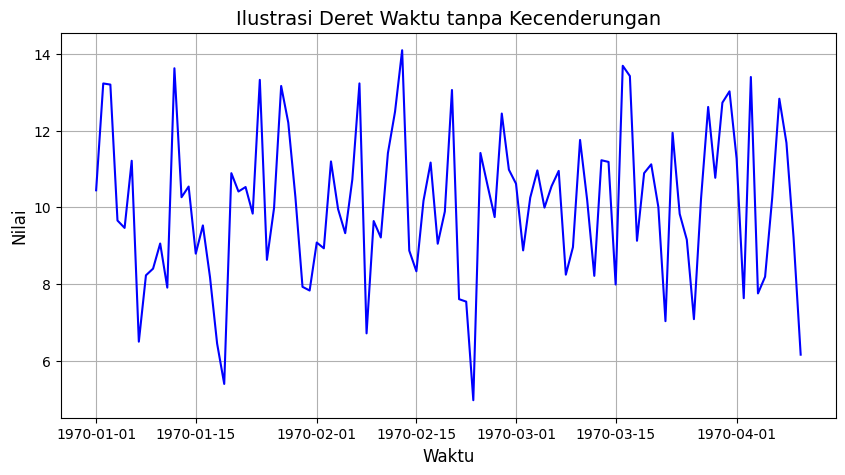

In [91]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

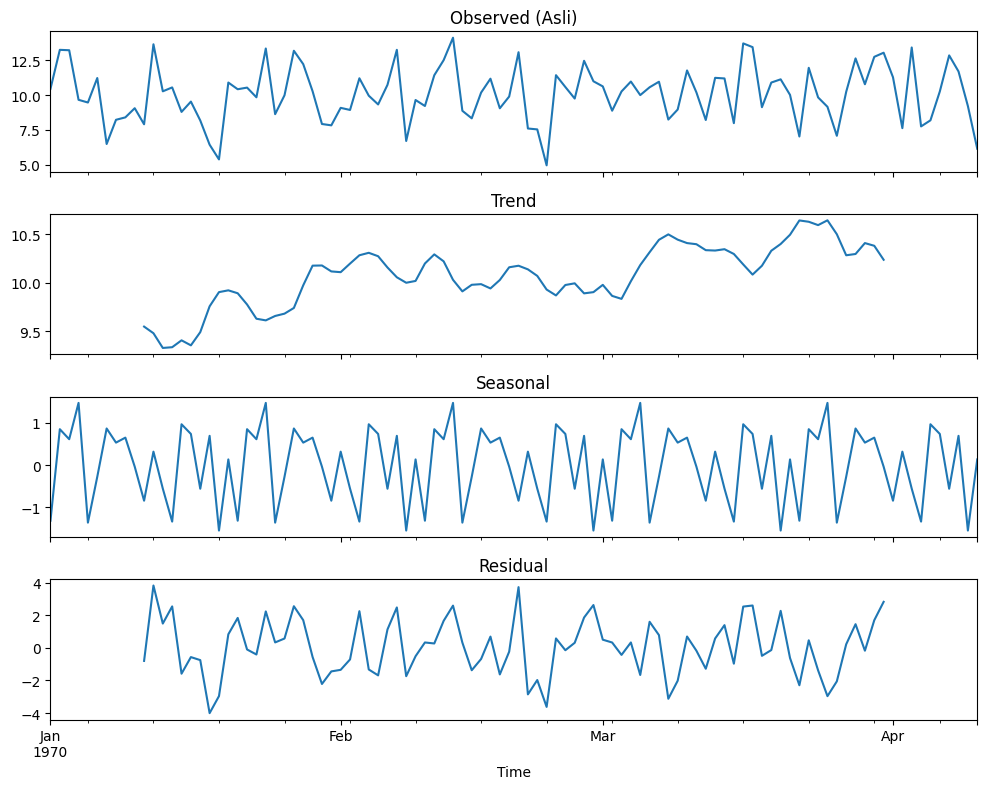

In [92]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

Bagaimana interpretasi dari plot tersebut?

Berdasarkan hasil dekomposisi, deret waktu menunjukkan tren positif yang relatif lemah dan pola musiman yang berulang, sedangkan residual memiliki variasi yang cukup besar. Komponen trend meningkat secara perlahan, sementara komponen seasonal berfluktuasi secara periodik dengan amplitudo yang relatif kecil. Residual yang berfluktuasi cukup besar di sekitar nol menunjukkan bahwa sebagian besar variasi jangka pendek pada data masih berasal dari faktor acak atau komponen yang belum dijelaskan oleh trend dan seasonal. Dengan demikian, deret ini lebih banyak dipengaruhi oleh fluktuasi acak dibandingkan oleh trend dan seasonal.